# SAIR — Lecture 3: Building GPT-2 from Scratch

**Module 5: GPT from Scratch** | Instructor: Mohammed Awad Ahmed

---

## What We're Building

A complete, working **GPT-2 Small (124M parameters)** — assembled piece by piece,
starting from raw token IDs and ending with a model that generates text.

## Learning Objectives

By the end of this notebook you will:

- Understand why both **token embeddings** and **positional embeddings** are needed
- Implement **Layer Normalization** and see its effect on activations
- Build the **GELU activation** and understand why GPT-2 uses it over ReLU
- Assemble a full **Transformer Block** — attention + FFN + two residual connections
- **Trace tensor shapes** at every single layer through the full network
- Know **where the 124M parameters live** (with charts)
- **Generate text** with the model — even before any training

---

## Module Progress

| Notebook | Topic | Status |
|----------|-------|--------|
| 1.DATA | Tokenization & DataLoader | ✅ Done |
| 2.ATTENTION | Multi-Head Causal Attention | ✅ Done |
| **3.GPT** | **GPT-2 Architecture** | **← You are here** |
| 4.TRAIN | Training Loop & Loss | ⬜ Next |
| 5.TRAIN_Pro | Advanced Training | ⬜ |
| 6.SFT | Supervised Fine-Tuning | ⬜ |


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import tiktoken
import matplotlib.pyplot as plt
import numpy as np
from gpt_viz import (
    draw_architecture, plot_embedding_heatmap, plot_positional_heatmap,
    plot_input_pipeline, plot_layernorm_effect, plot_gelu_comparison,
    plot_ffn_expansion, plot_gradient_flow, trace_gpt_shapes,
    plot_shape_journey, plot_parameter_breakdown, plot_gpt_variants,
)

torch.manual_seed(42)

# ── GPT-2 Small configuration ────────────────────────────────────────────
GPT_CONFIG_124 = {
    "vocab_size":     50257,   # BPE vocabulary (same as GPT-2)
    "context_length":  1024,   # Maximum sequence length
    "emb_dim":          768,   # Hidden / embedding dimension
    "n_heads":           12,   # Attention heads
    "n_layers":          12,   # Transformer blocks
    "dropout":          0.1,   # Dropout rate
    "qkv_bias":        False,  # No bias on QKV projections (GPT-2 style)
}

print("✓ Imports ready")
print(f"  GPT-2 Small: {GPT_CONFIG_124['n_layers']} layers | "
      f"d={GPT_CONFIG_124['emb_dim']} | "
      f"{GPT_CONFIG_124['n_heads']} heads | "
      f"vocab={GPT_CONFIG_124['vocab_size']:,}")


✓ Imports ready
  GPT-2 Small: 12 layers | d=768 | 12 heads | vocab=50,257


---

## The Big Picture: GPT-2 Architecture

Before diving into each component, let's see the full picture.

GPT-2 is a **decoder-only transformer** — it reads a sequence of tokens and predicts
the next token at each position. There is no encoder; no cross-attention.
The entire model is a single tower of transformer blocks that refine a representation
step by step until the final layer projects it into a probability distribution over the vocabulary.

<div align="center">
<img src="https://jalammar.github.io/images/gpt2/gpt2-self-attention-example-2.png"
     width="680" style="border-radius:6px; margin:10px 0">
<br><small><i>Image: Jay Alammar — The Illustrated GPT-2</i></small>
</div>

The four main stages:

| Stage | Operation | Output shape |
|-------|-----------|-------------|
| **Embedding** | token IDs → dense vectors + position | (B, T, 768) |
| **12 × Transformer Block** | attention + FFN + residuals | (B, T, 768) |
| **Final LayerNorm** | normalize before projection | (B, T, 768) |
| **Output head** | project to vocabulary logits | (B, T, 50257) |

The embedding dimension **768 stays constant all the way through** — only the final
linear layer explodes it back to vocabulary size.


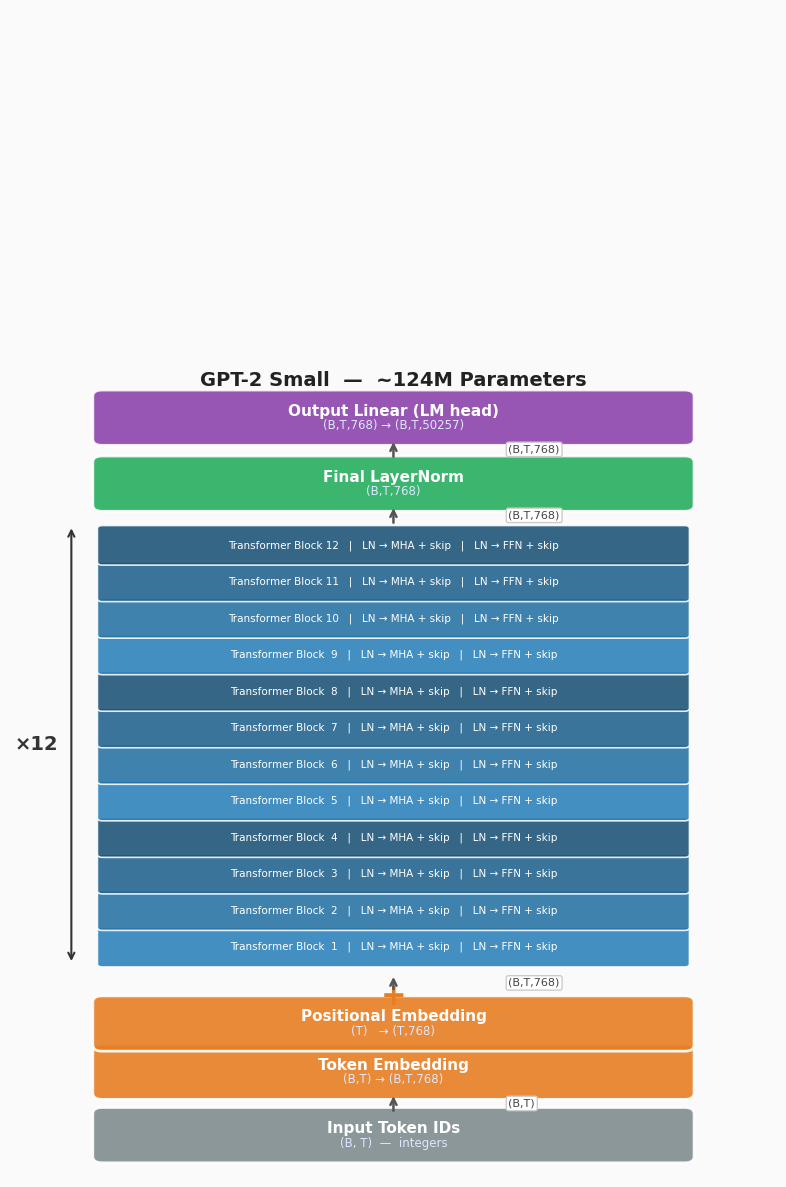

In [2]:
draw_architecture(GPT_CONFIG_124)

---

## Step 0 — Scaffold First, Build Later

A good engineering habit: before implementing every component in full detail,
**sketch the skeleton** to verify the end-to-end tensor flow.

We write a `DummyTransformerBlock` that passes data through unchanged.
This lets us confirm that shapes are correct and imports work — before any complex code.

The real `TransformerBlock` will replace it in Section 7.


In [3]:
class DummyTransformerBlock(nn.Module):
    """Placeholder — passes input unchanged. Shape: (B, T, C) → (B, T, C)"""
    def __init__(self, config): super().__init__()
    def forward(self, x):       return x   # identity; real block replaces this


class DummyGPT(nn.Module):
    """Skeleton GPT — used only to verify shapes before building real components."""
    def __init__(self, config):
        super().__init__()
        self.tok_emb = nn.Embedding(config["vocab_size"],     config["emb_dim"])
        self.pos_emb = nn.Embedding(config["context_length"], config["emb_dim"])
        self.dropout = nn.Dropout(config["dropout"])
        self.blocks  = nn.Sequential(
            *[DummyTransformerBlock(config) for _ in range(config["n_layers"])]
        )
        self.norm    = nn.LayerNorm(config["emb_dim"])
        self.head    = nn.Linear(config["emb_dim"], config["vocab_size"], bias=False)

    def forward(self, idx):               # idx: (B, T)  integer token IDs
        B, T = idx.shape
        x = self.tok_emb(idx)             # (B, T, C)
        x = x + self.pos_emb(torch.arange(T))   # (B, T, C)
        x = self.dropout(x)
        x = self.blocks(x)
        x = self.norm(x)
        return self.head(x)               # (B, T, vocab_size)


In [4]:
tokenizer = tiktoken.get_encoding("gpt2")
batch = torch.stack([
    torch.tensor(tokenizer.encode("Hello, I am")),
    torch.tensor(tokenizer.encode("GPT is fun")),
])

dummy  = DummyGPT(GPT_CONFIG_124)
logits = dummy(batch)

print(f"Input  shape: {tuple(batch.shape)}     — (batch=2, seq_len={batch.shape[1]})")
print(f"Output shape: {tuple(logits.shape)}  — (batch=2, seq_len, vocab=50257)")
print()
print("Skeleton works. Now we replace each DummyBlock with the real thing.")


Input  shape: (2, 4)     — (batch=2, seq_len=4)
Output shape: (2, 4, 50257)  — (batch=2, seq_len, vocab=50257)

Skeleton works. Now we replace each DummyBlock with the real thing.


---

## 1 — Token Embeddings

The tokenizer converts text into a sequence of integers (token IDs).
The first thing the model does is convert each integer into a **dense vector**.

### Why not feed integers directly?

Integers imply a numeric ordering: token 500 > token 3. That ordering is meaningless —
there is no reason "the" (token 262) should be "greater than" "a" (token 64).
Neural networks also need **continuous, differentiable** inputs for backpropagation to work.

### The solution: a learnable lookup table

$$E \in \mathbb{R}^{V \times d} \quad (50257 \times 768 \text{ for GPT-2 Small})$$

For token ID $i$, the embedding is simply the $i$-th row of $E$:

$$\text{embed}(i) = E[i, :]$$

All $50257 \times 768 = 38.6M$ values are **learned from data**.
The network decides what each of the 768 dimensions means — no human engineering required.

<div align="center">
<img src="https://jalammar.github.io/images/gpt2/gpt2-token-embeddings-wte.png"
     width="600" style="border-radius:6px; margin:10px 0">
<br><small><i>Image: Jay Alammar — The Illustrated GPT-2</i></small>
</div>


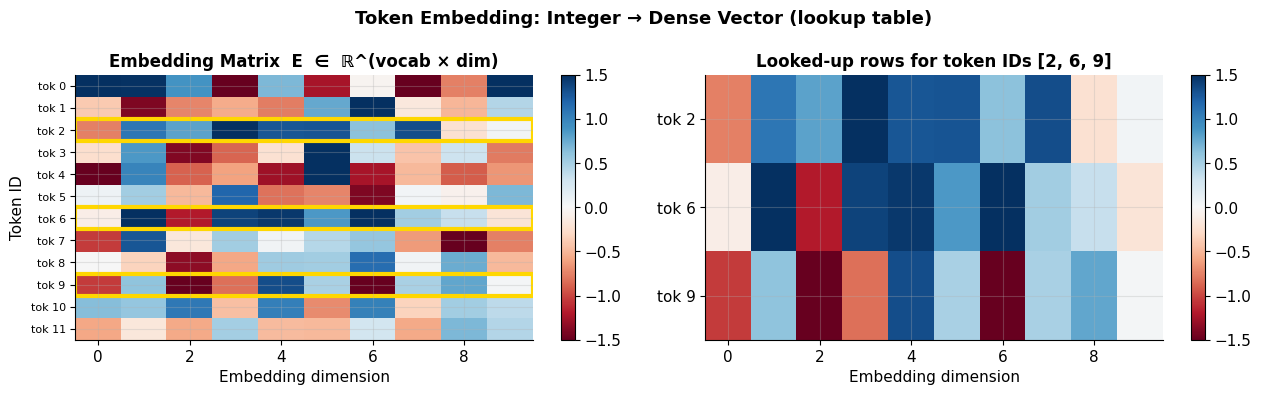

In [5]:
plot_embedding_heatmap()

In [6]:
# Tiny demo: vocab=6, dim=4
torch.manual_seed(42)
emb = nn.Embedding(6, 4)
print("Weight matrix (6 tokens × 4 dims):")
print(emb.weight.data.numpy().round(3))
print()
ids = torch.tensor([2, 4, 0])
print(f"Token IDs: {ids.tolist()}")
print("Corresponding rows from the table:")
print(emb(ids).detach().numpy().round(3))


Weight matrix (6 tokens × 4 dims):
[[ 1.927  1.487  0.901 -2.106]
 [ 0.678 -1.235 -0.043 -1.605]
 [ 0.356 -0.687 -0.493  0.241]
 [-1.111  0.092 -2.317 -0.217]
 [-0.31  -0.396  0.803 -0.622]
 [-0.592 -0.063 -0.829  0.331]]

Token IDs: [2, 4, 0]
Corresponding rows from the table:
[[ 0.356 -0.687 -0.493  0.241]
 [-0.31  -0.396  0.803 -0.622]
 [ 1.927  1.487  0.901 -2.106]]


> **Key Takeaway**
> An embedding layer is just a lookup table. `nn.Embedding(V, d)` stores a matrix of
> shape (V, d). Calling it with token IDs returns the corresponding rows.
> No math happens yet — it's pure indexing. The math starts in the transformer blocks.

> **Common Mistake**
> Forgetting that the embedding output is `(B, T, d)` — not `(B, T)`.
> After embedding, every token is a vector, not a scalar.


---

## 2 — Positional Encoding

### The Position Problem

After token embedding, the model has a set of vectors — but **no sense of order**.
Self-attention is permutation-equivariant: it treats its inputs as a bag, not a sequence.

The sentence *"dog bites man"* and *"man bites dog"* would produce **identical attention patterns**
without positional information. That's catastrophic for a language model.

### GPT-2's Solution: Learned Positional Embeddings

A second lookup table $P \in \mathbb{R}^{L \times d}$ (1024 × 768) indexed by **position**:

$$\text{pos\_embed}(t) = P[t, :]$$

The final input to the transformer is the **sum** of both embeddings:

$$\mathbf{x}_t = E[\text{token\_id}_t] + P[t]$$

This encodes both **what** the token is and **where** it sits in the sequence.

> **Original Transformer vs GPT-2**: Vaswani et al. (2017) used fixed sinusoidal
> functions for positions. GPT-2 learns them from data — simpler and equally effective.

<div align="center">
<img src="https://jalammar.github.io/images/gpt2/gpt2-positional-encoding.png"
     width="600" style="border-radius:6px; margin:10px 0">
<br><small><i>Image: Jay Alammar — The Illustrated GPT-2</i></small>
</div>


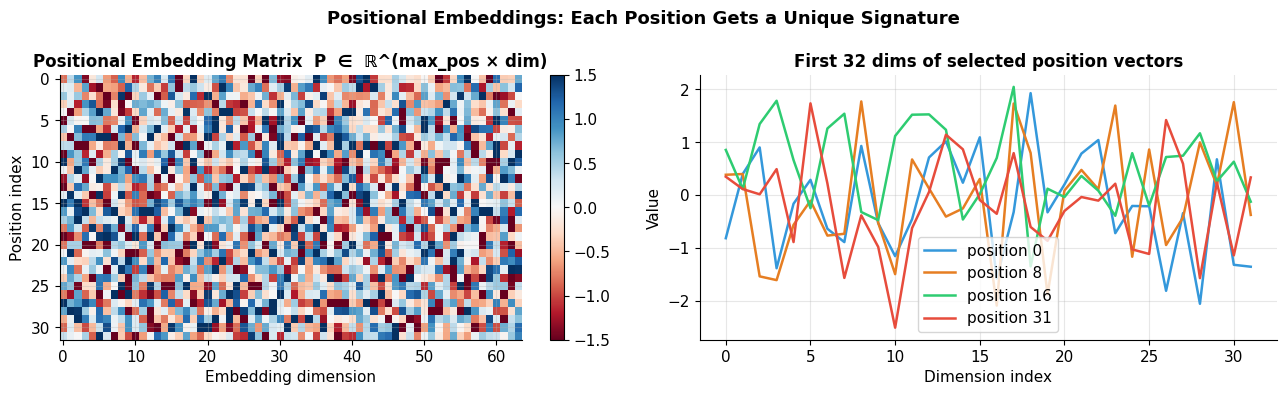

In [7]:
plot_positional_heatmap()

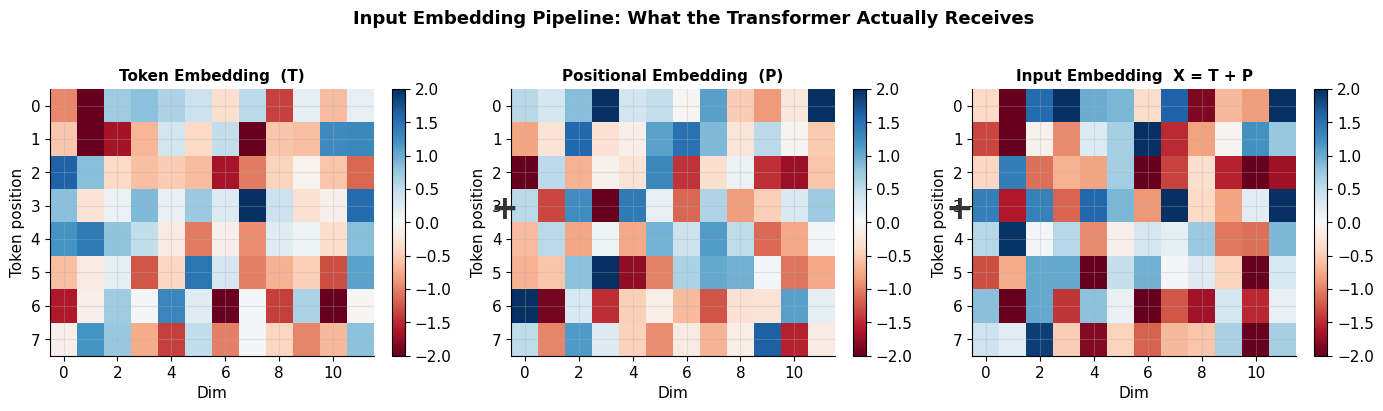

In [8]:
plot_input_pipeline()

> **Key Takeaway**
> The transformer doesn't know about order by default.
> Positional embeddings inject order by adding a unique signature to every position.
> After `x = token_emb + pos_emb`, each vector carries both semantic *and* positional information.

> **Common Mistake**
> Using `torch.arange(T)` without `.to(device)` — works on CPU but crashes on GPU.
> Always write: `torch.arange(T, device=idx.device)`


---

## 3 — Layer Normalization

### The Problem: Activations Drift in Deep Networks

Each layer transforms its input — multiply by weights, add bias, apply activation.
Over 12 stacked blocks, activation values drift: their **mean shifts away from zero**
and their **variance explodes or collapses**. The gradient signal follows:
early layers receive either zero (vanishing) or infinity (exploding) gradients. Training fails.

### The Fix: Normalize After Every Sub-Layer

Layer Normalization computes, for each sample independently across the feature dimension:

$$\hat{x} = \frac{x - \mu}{\sqrt{\sigma^2 + \varepsilon}}$$

Then two **learnable parameters** restore expressive power:

$$\text{output} = \gamma \cdot \hat{x} + \beta$$

- $\gamma$ (scale) initialized to **1** — learned by the network
- $\beta$ (shift) initialized to **0** — learned by the network
- $\varepsilon = 10^{-5}$ prevents division by zero

The network can undo normalization if needed — $\gamma$ and $\beta$ give it the freedom to do so.

### LayerNorm vs BatchNorm

| | BatchNorm | LayerNorm |
|--|-----------|-----------|
| Normalizes over | Batch dimension | Feature dimension |
| Works at batch_size=1 | No | **Yes** |
| Consistent at inference | Requires running stats | Always consistent |
| Used in | CNNs | **Transformers, RNNs** |

LayerNorm is essential for transformers because **autoregressive generation runs one token
at a time** — batch size = 1. BatchNorm would fail.

<div align="center">
<img src="https://jalammar.github.io/images/t/transformer_resideual_layer_norm_3.png"
     width="580" style="border-radius:6px; margin:10px 0">
<br><small><i>Image: Jay Alammar — The Illustrated Transformer</i></small>
</div>


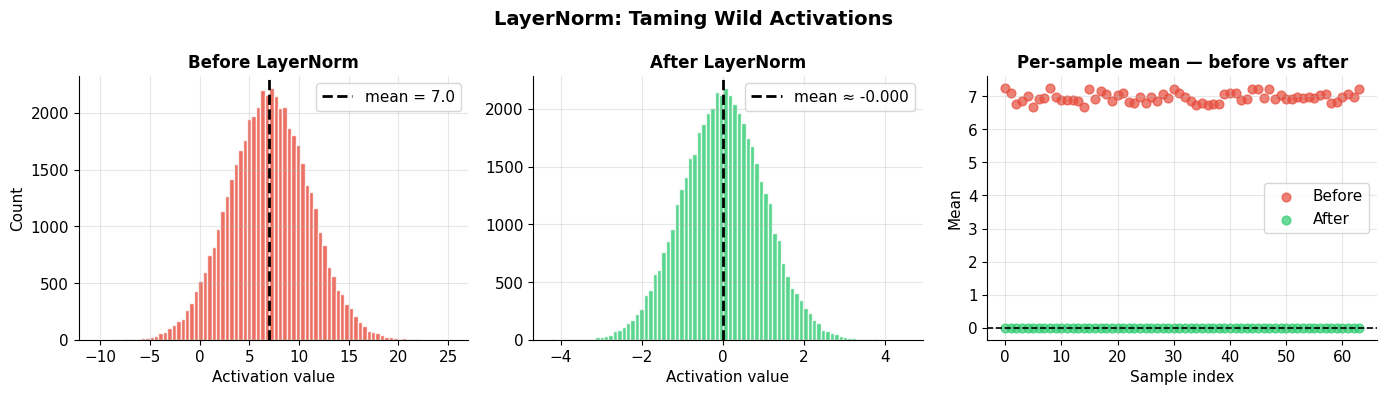

Before  — mean: 6.97,  std: 4.00
After   — mean: -0.0000, std: 1.0000


In [9]:
plot_layernorm_effect()

In [10]:
class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.gamma = nn.Parameter(torch.ones(emb_dim))    # scale — learned
        self.beta  = nn.Parameter(torch.zeros(emb_dim))   # shift — learned
        self.eps   = 1e-5

    def forward(self, x):
        mean  = x.mean(dim=-1, keepdim=True)
        var   = x.var(dim=-1, keepdim=True, unbiased=False)
        x_hat = (x - mean) / torch.sqrt(var + self.eps)
        return self.gamma * x_hat + self.beta

# Verify it matches PyTorch's built-in
torch.manual_seed(0)
x          = torch.randn(4, 768)
custom_out = LayerNorm(768)(x)
torch_out  = nn.LayerNorm(768)(x)
diff       = (custom_out - torch_out).abs().max().item()
print(f"Max difference vs nn.LayerNorm: {diff:.2e}  ✓  (floating-point precision only)")


Max difference vs nn.LayerNorm: 4.77e-07  ✓  (floating-point precision only)


> **Key Takeaway**
> LayerNorm is a per-sample normalization over the feature dimension.
> It keeps activations well-scaled throughout the entire 12-block stack,
> making the gradient signal strong and consistent all the way back to layer 1.
>
> In GPT-2, LayerNorm is applied **before** each sub-layer (pre-norm style),
> which is more stable than the original transformer's post-norm design.


---

## 4 — GELU Activation Function

Every FeedForward network needs a nonlinearity. GPT-2 uses **GELU** (Gaussian Error Linear Unit).

### Why not ReLU?

ReLU has a "hard" zero cutoff: $\text{ReLU}(x) = \max(0, x)$.

This creates **dead neurons**: once a neuron's pre-activation is negative,
its gradient is exactly zero — it can never recover and stops learning.
With 768 dimensions and 12 layers, dead neurons accumulate and hurt performance.

### GELU: Soft Gating

GELU multiplies the input by the probability that a standard Gaussian would be smaller:

$$\text{GELU}(x) = x \cdot \Phi(x) \quad \text{where } \Phi \text{ is the Gaussian CDF}$$

**Practical approximation used in GPT-2:**

$$\text{GELU}(x) \approx 0.5 \cdot x \cdot \left(1 + \tanh\!\left(\sqrt{\frac{2}{\pi}}\,(x + 0.044715\,x^3)\right)\right)$$

The key property: **GELU allows small negative outputs** near $x=0$.
This gives every neuron a chance to contribute even for slightly negative inputs,
preventing the dead neuron problem.

| Property | ReLU | GELU |
|----------|------|------|
| Hard zero at x=0 | Yes | No — smooth |
| Dead neurons | Common | Rare |
| Gradient at x=0 | Undefined | Smooth |
| Used in | Earlier networks | GPT-2, BERT, most LLMs |


In [11]:
class GELU(nn.Module):
    def forward(self, x):
        return 0.5 * x * (1.0 + torch.tanh(
            torch.sqrt(torch.tensor(2.0 / torch.pi)) * (x + 0.044715 * x.pow(3))
        ))


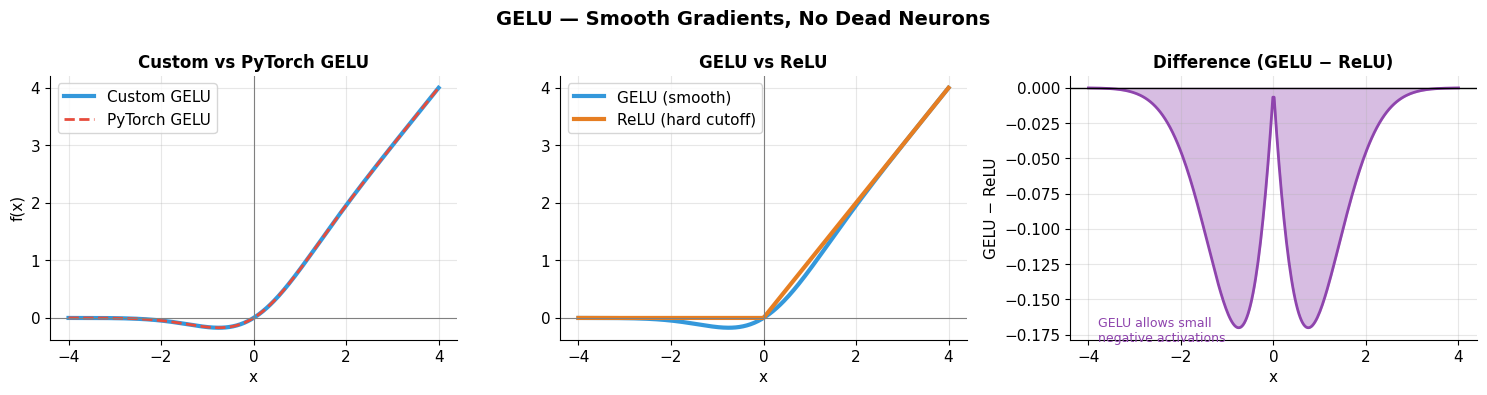

Max difference between custom and PyTorch GELU: 4.73e-04  ✓


In [12]:
plot_gelu_comparison()

> **Key Takeaway**
> GELU is a smooth, probabilistic gating function. Near zero it allows small negative
> values through — unlike ReLU which hard-clips them. This prevents dead neurons
> and produces a smoother loss landscape that optimizers navigate more easily.


---

## 5 — FeedForward Network (FFN)

After attention has mixed information **across tokens**, the FeedForward block
processes each token **independently** — a per-position transformation.

Think of it this way:
- **Attention** answers: *"which other tokens should I look at?"*
- **FeedForward** answers: *"now that I've gathered context, what should I compute?"*

Researchers have found that factual knowledge is largely stored in the FFN weights
(e.g., "Paris is the capital of France" lives in some FFN neurons).

### Architecture

$$x \xrightarrow{W_1 \in \mathbb{R}^{d \times 4d}} \text{GELU} \xrightarrow{W_2 \in \mathbb{R}^{4d \times d}} \text{output}$$

$$768 \xrightarrow{\times 4} 3072 \xrightarrow{\div 4} 768$$

The **4× expansion** creates a richer working space for computation.
It was chosen in the original Transformer paper and has proven empirically robust across scales.


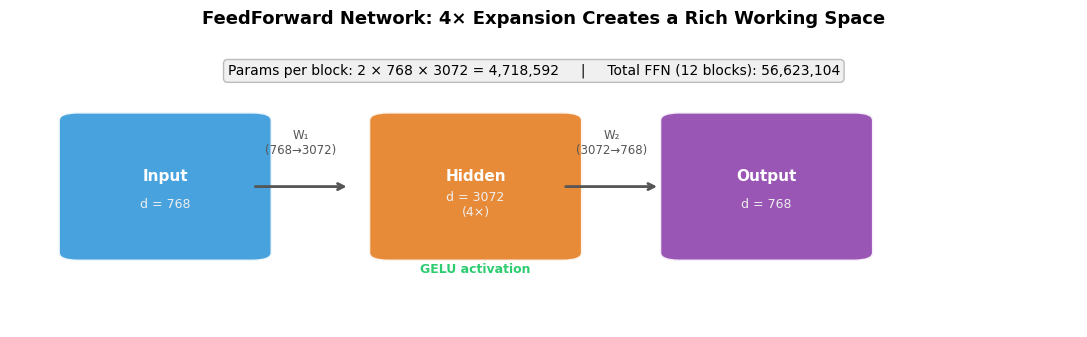

In [13]:
plot_ffn_expansion(GPT_CONFIG_124)

In [14]:
class FeedForward(nn.Module):
    def __init__(self, config):
        super().__init__()
        d = config["emb_dim"]
        self.net = nn.Sequential(
            nn.Linear(d, 4 * d),         # expand:  768 → 3072
            GELU(),                       # smooth nonlinearity
            nn.Linear(4 * d, d),         # project: 3072 → 768
            nn.Dropout(config["dropout"]),
        )

    def forward(self, x):
        return self.net(x)    # shape unchanged: (B, T, d) → (B, T, d)


> **Key Takeaway**
> FFN runs independently on each token — no information crosses token boundaries here.
> It acts as the model's "memory": factual knowledge and reasoning patterns are
> stored in the FFN weights. Attention decides *what to look at*; FFN decides *what to do*.
>
> The 4× expansion (768→3072→768) in GPT-2 Small adds
> **2 × 768 × 3072 × 12 = 56.6M parameters** — nearly half the model.


---

## 6 — Residual (Skip) Connections

### The Vanishing Gradient Problem

Backpropagation multiplies gradients together as it flows backwards through layers.
With 12 blocks and two sub-layers each, the gradient passes through **24 multiplications**.

If each weight matrix has values slightly less than 1, gradients shrink exponentially:
$$0.9^{24} \approx 0.08$$

Layer 1 receives a gradient 92% smaller than layer 12. Early layers learn almost nothing.

### The Fix: Add a Direct Path

Residual connections add the **input** directly to the output of each sub-layer:

$$\text{output} = F(x) + x$$

Now the gradient has **two paths** back: through $F(x)$ and directly through $x$.
The $x$ path carries the gradient unchanged — no shrinkage.

### In GPT-2 (Pre-Norm Style)

Each Transformer Block applies two residual connections:

```
x = x + Attention(LayerNorm(x))    ← first residual
x = x + FFN(LayerNorm(x))          ← second residual
```

Note that LayerNorm comes **before** the sub-layer (pre-norm), unlike the original
Transformer paper which normalized after. Pre-norm trains more stably at scale.

<div align="center">
<img src="https://jalammar.github.io/images/t/transformer_resideual_layer_norm_2.png"
     width="400" style="border-radius:6px; margin:10px 0">
<br><small><i>Image: Jay Alammar — The Illustrated Transformer</i></small>
</div>


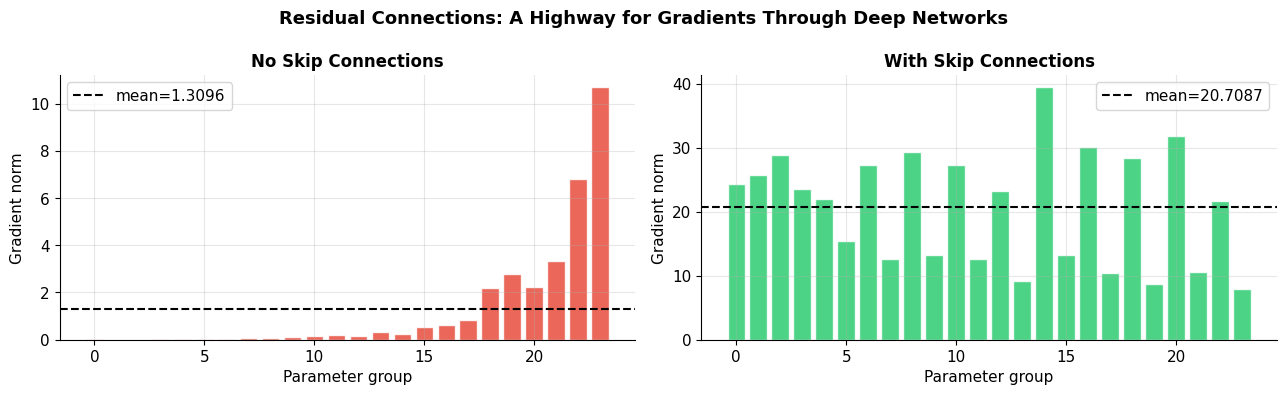

In [15]:
plot_gradient_flow()

> **Key Takeaway**
> Without residuals, deep networks suffer from vanishing gradients — early layers
> stop learning because their gradient signal is essentially zero.
> Residual connections provide a gradient highway: the signal flows back unimpeded,
> enabling training of very deep networks (12, 24, even 96 layers).

> **Common Mistake**
> Applying LayerNorm after the residual sum (post-norm) instead of before the sub-layer
> (pre-norm). GPT-2 uses **pre-norm** — normalize first, then attention/FFN, then add skip.
> Getting this order wrong makes training less stable.


---

## 7 — The Transformer Block

We now have all ingredients. The Transformer Block combines them:

```
Input x  (B, T, d)
  │
  ├── LayerNorm → MultiHeadAttention ──────────┐
  └──────────────────────────────── + (skip) ──► x₁  (B, T, d)
                                                  │
  ├── LayerNorm → FeedForward ──────────────────┐
  └──────────────────────────────── + (skip) ──► x₂  (B, T, d)
```

Two sub-layers, each with:
1. **Pre-LayerNorm** — normalize the input before processing
2. **The sub-layer itself** (attention or FFN)
3. **Dropout** — regularization
4. **Residual add** — add the original input back

GPT-2 stacks **12 of these blocks**. Each refines the representation —
early blocks tend to learn syntax and local patterns,
later blocks learn longer-range semantic relationships.


In [16]:
# ── From Notebook 2: Causal Multi-Head Self-Attention ────────────────────
# Full derivation and intuition in 2.ATTENTION.ipynb.
# Here we use it as a building block.

class MultiHeadAttention(nn.Module):
    """Causal multi-head self-attention.  (B, T, d) → (B, T, d)"""
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, bias=False):
        super().__init__()
        assert d_out % num_heads == 0, "d_out must be divisible by num_heads"
        self.d_out     = d_out
        self.num_heads = num_heads
        self.head_dim  = d_out // num_heads

        self.W_q  = nn.Linear(d_in, d_out, bias=bias)
        self.W_k  = nn.Linear(d_in, d_out, bias=bias)
        self.W_v  = nn.Linear(d_in, d_out, bias=bias)
        self.proj = nn.Linear(d_out, d_out)           # output projection
        self.drop = nn.Dropout(dropout)

        # Upper-triangular mask: prevents attending to future tokens
        self.register_buffer(
            "mask",
            torch.triu(torch.ones(context_length, context_length), diagonal=1)
        )

    def forward(self, x):
        B, T, _ = x.shape
        # Project and split into heads
        Q = self.W_q(x).view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        K = self.W_k(x).view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        V = self.W_v(x).view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        # Scaled dot-product attention + causal mask
        scores  = torch.matmul(Q, K.transpose(-2, -1)) * self.head_dim ** -0.5
        scores  = scores.masked_fill(self.mask[:T, :T].bool(), float("-inf"))
        weights = self.drop(torch.softmax(scores, dim=-1))
        # Combine heads and project
        out = torch.matmul(weights, V).transpose(1, 2).contiguous().view(B, T, self.d_out)
        return self.proj(out)


In [17]:
class TransformerBlock(nn.Module):
    def __init__(self, config):
        super().__init__()
        d = config["emb_dim"]
        self.norm1 = nn.LayerNorm(d)
        self.attn  = MultiHeadAttention(
            d_in=d, d_out=d,
            context_length=config["context_length"],
            dropout=config["dropout"],
            num_heads=config["n_heads"],
            bias=config["qkv_bias"],
        )
        self.norm2 = nn.LayerNorm(d)
        self.ffn   = FeedForward(config)
        self.drop  = nn.Dropout(config["dropout"])

    def forward(self, x):
        # Sub-layer 1: Multi-Head Attention (pre-norm + residual)
        x = x + self.drop(self.attn(self.norm1(x)))
        # Sub-layer 2: FeedForward         (pre-norm + residual)
        x = x + self.drop(self.ffn(self.norm2(x)))
        return x


In [18]:
block = TransformerBlock(GPT_CONFIG_124)
x_in  = torch.randn(2, 10, GPT_CONFIG_124["emb_dim"])
x_out = block(x_in)

print(f"Input  shape : {tuple(x_in.shape)}")
print(f"Output shape : {tuple(x_out.shape)}   ← shape preserved (key property)")
print(f"Params/block : {sum(p.numel() for p in block.parameters()):,}")


Input  shape : (2, 10, 768)
Output shape : (2, 10, 768)   ← shape preserved (key property)
Params/block : 7,085,568


> **Key Takeaway**
> The Transformer Block is the core repeating unit. It takes `(B, T, d)` and returns
> `(B, T, d)` — shape preserved. This is what makes stacking 12 blocks trivial.
> Inside, attention handles cross-token interaction; FFN handles per-token computation.
> Residuals and LayerNorm keep training stable throughout.


---

## 8 — Tensor Shape Journey

One of the most powerful debugging skills for transformers: knowing the **exact shape
at every stage**. When something breaks, wrong shapes are the first thing to check.

Let's trace a batch of 2 sequences of length 10 through every single layer.


In [19]:
trace_gpt_shapes(GPT_CONFIG_124, B=2, T=10)

Stage                                                            Shape
────────────────────────────────────────────────────────────────────────
Input token IDs                                                (2, 10)
After tok_emb lookup                                      (2, 10, 768)
After pos_emb lookup                                         (10, 768)
Input embedding  (tok + pos)                              (2, 10, 768)
After Dropout                                             (2, 10, 768)
After TransformerBlock  1                                 (2, 10, 768)
After TransformerBlock  2                                 (2, 10, 768)
After TransformerBlock  3                                 (2, 10, 768)
After TransformerBlock  4                                 (2, 10, 768)
After TransformerBlock  5                                 (2, 10, 768)
After TransformerBlock  6                                 (2, 10, 768)
After TransformerBlock  7                                 (2, 10, 768)
Afte

[('Input token IDs', (2, 10)),
 ('After tok_emb lookup', (2, 10, 768)),
 ('After pos_emb lookup', (10, 768)),
 ('Input embedding  (tok + pos)', (2, 10, 768)),
 ('After Dropout', (2, 10, 768)),
 ('After TransformerBlock  1', (2, 10, 768)),
 ('After TransformerBlock  2', (2, 10, 768)),
 ('After TransformerBlock  3', (2, 10, 768)),
 ('After TransformerBlock  4', (2, 10, 768)),
 ('After TransformerBlock  5', (2, 10, 768)),
 ('After TransformerBlock  6', (2, 10, 768)),
 ('After TransformerBlock  7', (2, 10, 768)),
 ('After TransformerBlock  8', (2, 10, 768)),
 ('After TransformerBlock  9', (2, 10, 768)),
 ('After TransformerBlock 10', (2, 10, 768)),
 ('After TransformerBlock 11', (2, 10, 768)),
 ('After TransformerBlock 12', (2, 10, 768)),
 ('After Final LayerNorm', (2, 10, 768)),
 ('Logits (output linear)', (2, 10, 50257))]

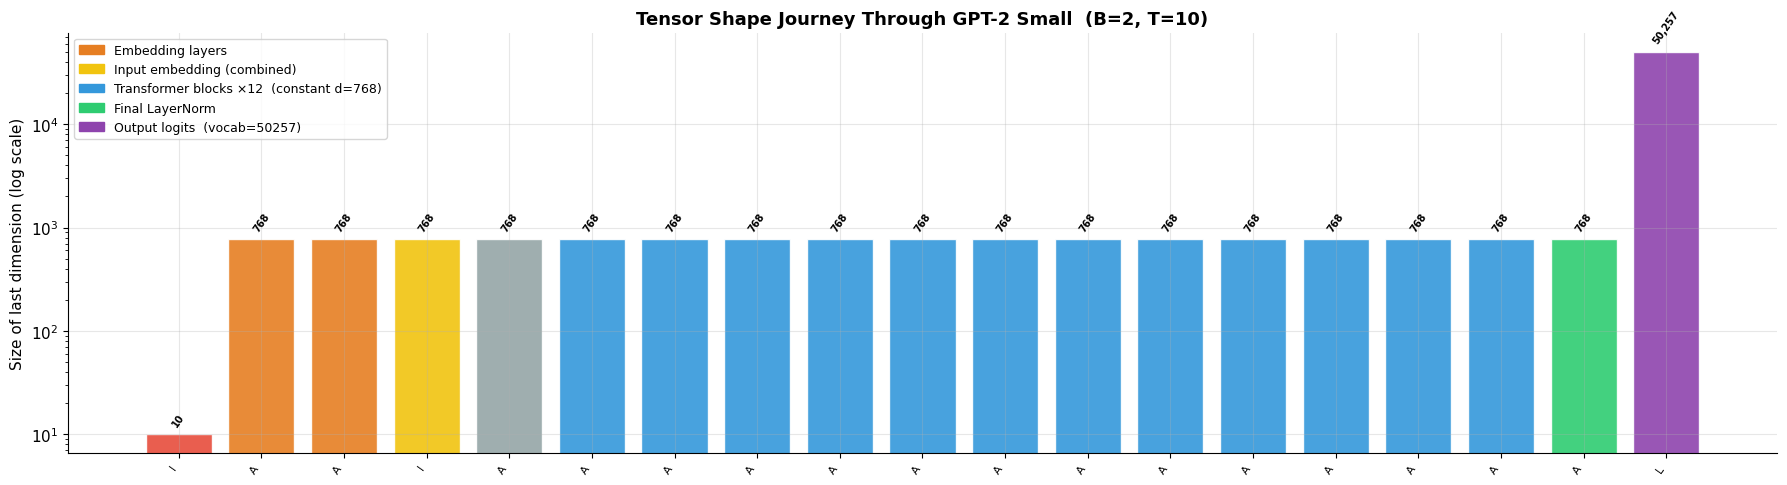

The embedding dimension stays CONSTANT at 768 through all 12 blocks. Only the final projection expands it to 50257.


In [20]:
plot_shape_journey(GPT_CONFIG_124, B=2, T=10)

> **Key Takeaway**
> The embedding dimension **d = 768 stays constant** from the first embedding layer
> through all 12 transformer blocks to the final LayerNorm.
> Only the last linear layer changes the shape — projecting 768 → 50,257.
> This constant-shape design is what allows arbitrary stacking of transformer blocks.


---

## 9 — Building GPT-2 Small (124M Parameters)

Every component is ready. Now we assemble them into the full model.

The `GPTModel.forward()` does exactly what the shape journey showed:
1. Convert token IDs → embeddings + positions
2. Pass through 12 TransformerBlocks sequentially
3. Apply final LayerNorm
4. Project to vocabulary logits

One important detail: **weight tying**.
GPT-2 shares the weight matrix between the **token embedding** and the **output linear layer**.
The intuition: the same representation that maps tokens to vectors at the input
is reused (transposed) to score vectors back to tokens at the output.
This saves $50257 \times 768 = 38.6M$ parameters and consistently improves quality.


In [21]:
class GPTModel(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.tok_emb = nn.Embedding(config["vocab_size"],     config["emb_dim"])
        self.pos_emb = nn.Embedding(config["context_length"], config["emb_dim"])
        self.drop    = nn.Dropout(config["dropout"])
        self.blocks  = nn.Sequential(
            *[TransformerBlock(config) for _ in range(config["n_layers"])]
        )
        self.norm    = nn.LayerNorm(config["emb_dim"])
        self.head    = nn.Linear(config["emb_dim"], config["vocab_size"], bias=False)

        # Weight tying: output head shares the token embedding matrix
        # Saves 38.6M params; standard in GPT-2 and most modern LLMs
        self.head.weight = self.tok_emb.weight

    def forward(self, idx):                                    # idx: (B, T)
        B, T = idx.shape
        tok  = self.tok_emb(idx)                               # (B, T, C)
        pos  = self.pos_emb(torch.arange(T, device=idx.device))  # (T, C)
        x    = self.drop(tok + pos)                            # (B, T, C)
        x    = self.blocks(x)                                  # (B, T, C)
        x    = self.norm(x)                                    # (B, T, C)
        return self.head(x)                                    # (B, T, vocab_size)


In [22]:
gpt = GPTModel(GPT_CONFIG_124)

B, T      = 2, 10
ids       = torch.randint(0, GPT_CONFIG_124["vocab_size"], (B, T))
logits    = gpt(ids)
total_p   = sum(p.numel() for p in gpt.parameters())

print(f"Input  shape : {tuple(ids.shape)}")
print(f"Output shape : {tuple(logits.shape)}")
print(f"Total params : {total_p:,}  ({total_p/1e6:.1f}M)")
print()
print("Note: weight tying means tok_emb and head share one matrix (38.6M params).")
print(f"Without tying it would be ~{(total_p + 50257*768)/1e6:.0f}M.")


Input  shape : (2, 10)
Output shape : (2, 10, 50257)
Total params : 124,412,160  (124.4M)

Note: weight tying means tok_emb and head share one matrix (38.6M params).
Without tying it would be ~163M.


---

## 10 — Where Do the 124M Parameters Live?

We say "124M parameters" but rarely ask: **where exactly are they?**
Understanding the distribution matters for:
- Knowing which layers to fine-tune (or freeze) efficiently
- Understanding why scaling the FFN or depth helps
- Debugging: if a layer has unexpectedly many/few params, something is wrong


Component                                 Params    Share
──────────────────────────────────────────────────────────
Token Embedding                       38,597,376   23.68%
Positional Embedding                     786,432    0.48%
Transformer Blocks ×12                85,026,816   52.16%
Final LayerNorm                            1,536    0.00%
Output Linear (LM head)
[weight-tied → 0 extra]      38,597,376   23.68%
──────────────────────────────────────────────────────────
TOTAL                                163,009,536  100.00%


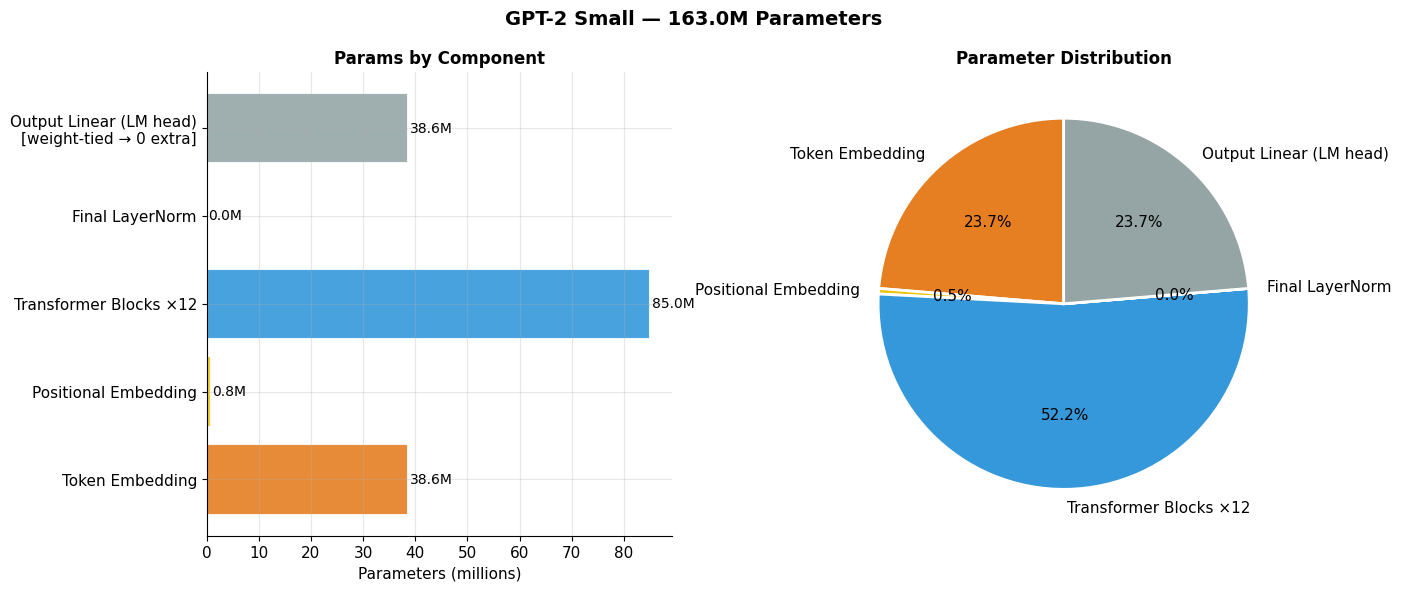

In [23]:
plot_parameter_breakdown(gpt)

> **Key Takeaway**
> The Transformer blocks hold the vast majority of parameters (~85M out of 124M).
> The 12 FFN layers alone account for ~56M. This is why scaling the FFN width
> (increasing the 4× factor) is one of the most direct ways to add capacity.
> Token embeddings hold ~39M — shared with the output head, so they count once.


---

## 11 — The GPT-2 Family

GPT-2 was released in four sizes in 2019. Our implementation supports all of them
by changing a single config dictionary. This is the power of a well-abstracted design.

| Model | Layers | Heads | d_model | ~Params |
|-------|--------|-------|---------|---------|
| Small  | 12 | 12 | 768  | 124M |
| Medium | 24 | 16 | 1024 | 355M |
| Large  | 36 | 20 | 1280 | 774M |
| XL     | 48 | 25 | 1600 | 1.5B |

Notice: scaling happens in **two directions** simultaneously — depth (more layers)
and width (larger embedding dimension). Both matter. Depth increases compositional
complexity; width increases per-layer representation capacity.


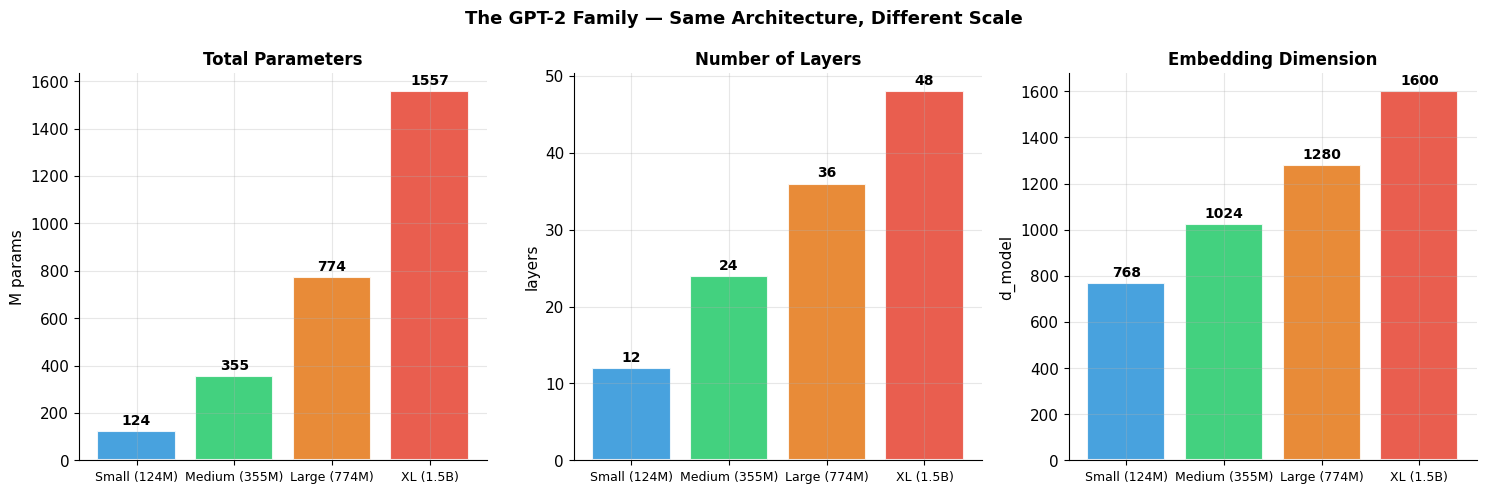

In [24]:
GPT_CONFIGS = {
    "Small (124M)":  {"vocab_size":50257,"context_length":1024,"emb_dim":768,  "n_heads":12,"n_layers":12,"dropout":0.1,"qkv_bias":False},
    "Medium (355M)": {"vocab_size":50257,"context_length":1024,"emb_dim":1024, "n_heads":16,"n_layers":24,"dropout":0.1,"qkv_bias":False},
    "Large (774M)":  {"vocab_size":50257,"context_length":1024,"emb_dim":1280, "n_heads":20,"n_layers":36,"dropout":0.1,"qkv_bias":False},
    "XL (1.5B)":     {"vocab_size":50257,"context_length":1024,"emb_dim":1600, "n_heads":25,"n_layers":48,"dropout":0.1,"qkv_bias":False},
}

plot_gpt_variants(GPT_CONFIGS, GPTModel)


---

## 12 — Generating Text

The model is built. Let's use it.

**Important**: with random (untrained) weights the output will be nonsense — expected.
The model has never seen data. What we're testing is the **generation pipeline**,
not the quality of the output. Notebook 4 trains the model; this notebook builds it.

### How Greedy Decoding Works

```
Prompt tokens  →  model  →  logits (B, T, 50257)
                                │
                        last position only   (B, 50257)
                                │
                            argmax()          ← pick the most likely next token
                                │
                        append to sequence
                                │
                            repeat ...
```

This is the simplest possible generation strategy.
Notebook 4 will also cover temperature sampling and top-k filtering.


In [ ]:
def generate(model, prompt_ids, max_new_tokens=20, context_length=1024):
    """
    Greedy autoregressive generation.
    prompt_ids : LongTensor  (1, T)  —  starting token IDs
    Returns    : LongTensor  (1, T + max_new_tokens)
    """
    model.eval()
    with torch.no_grad():
        for _ in range(max_new_tokens):
            ids_crop   = prompt_ids[:, -context_length:]      # crop to context window
            logits     = model(ids_crop)                       # (1, T, vocab_size)
            next_logit = logits[:, -1, :]                      # (1, vocab_size) — last pos
            next_id    = next_logit.argmax(dim=-1, keepdim=True)
            prompt_ids = torch.cat([prompt_ids, next_id], dim=1)
    return prompt_ids


In [26]:
tokenizer   = tiktoken.get_encoding("gpt2")
prompt      = "Once upon a time"
prompt_ids  = torch.tensor(tokenizer.encode(prompt)).unsqueeze(0)  # (1, T)

gpt_fresh   = GPTModel(GPT_CONFIG_124)                 # fresh random weights
output_ids  = generate(gpt_fresh, prompt_ids, max_new_tokens=20)
output_text = tokenizer.decode(output_ids[0].tolist())

print("Prompt   :", prompt)
print("─" * 60)
print("Generated (random weights — nonsense expected):")
print(output_text)
print()
print(f"Prompt tokens   : {prompt_ids.shape[1]}")
print(f"Generated total : {output_ids.shape[1]} tokens")
print()
print("The pipeline works end-to-end.")
print("After training (Notebook 4), generate() will produce coherent English.")


Prompt   : Once upon a time
────────────────────────────────────────────────────────────
Generated (random weights — nonsense expected):
Once upon a time time time time time time time time time time time time time time time time time time time time time

Prompt tokens   : 4
Generated total : 24 tokens

The pipeline works end-to-end.
After training (Notebook 4), generate() will produce coherent English.


---

## Common Mistakes to Avoid

These are the bugs that trip up almost everyone when building transformers from scratch.

---

**1. Forgetting `device=idx.device` in positional embeddings**

```python
# Wrong — crashes when model is on GPU
pos = self.pos_emb(torch.arange(T))

# Correct
pos = self.pos_emb(torch.arange(T, device=idx.device))
```

---

**2. Not registering the causal mask as a buffer**

```python
# Wrong — the mask won't move to GPU with .to(device)
self.mask = torch.triu(torch.ones(ctx, ctx), diagonal=1)

# Correct — buffers follow the module to any device
self.register_buffer("mask", torch.triu(torch.ones(ctx, ctx), diagonal=1))
```

---

**3. Expecting 124M parameters without weight tying**

Without `self.head.weight = self.tok_emb.weight`, the model has ~163M parameters.
The standard GPT-2 Small is 124M because of weight tying.
If you load pretrained GPT-2 weights without tying, shapes will mismatch.

---

**4. Post-norm vs pre-norm confusion**

```python
# Wrong (post-norm — original Transformer paper)
x = self.norm1(x + self.attn(x))

# Correct (pre-norm — GPT-2 style, more stable)
x = x + self.attn(self.norm1(x))
```

---

**5. Wrong attention mask application**

The mask should fill with `-inf` (not 0) so softmax produces 0 probability:

```python
# Wrong — adds 0 but softmax still assigns positive probability
scores[mask] = 0

# Correct — -inf → softmax → 0
scores = scores.masked_fill(mask.bool(), float("-inf"))
```


---

## Exercises

---

### Exercise 1 — Manual Parameter Count

Without running code, calculate the expected number of parameters in the **Token Embedding** layer.
- `vocab_size = 50257`, `emb_dim = 768`
- How many numbers are stored in this single layer?

Verify with:
```python
sum(p.numel() for p in gpt.tok_emb.parameters())
```

**Hint**: It's just a matrix multiplication away — `V × d`.

---

### Exercise 2 — Remove Weight Tying

Create a version of `GPTModel` without weight tying.
How many parameters does it have compared to 124M?
What does this tell you about how much weight tying saves?

```python
# Remove this line and check the parameter count:
# self.head.weight = self.tok_emb.weight
```

---

### Exercise 3 — Swap the Activation Function

Replace `GELU` with `nn.SiLU()` (called Swish) in `FeedForward`.
SiLU is used in Llama 2, Mistral, and most post-GPT LLMs.

```python
self.net = nn.Sequential(
    nn.Linear(d, 4 * d),
    nn.SiLU(),              # ← swap here
    nn.Linear(4 * d, d),
    nn.Dropout(config["dropout"]),
)
```

Does the output shape change? Does the parameter count change?
Run `generate()` with both and compare outputs (both are random — just check shapes).

---

### Exercise 4 — Scale to GPT-2 Medium

Instantiate a GPT-2 Medium model using:
```python
GPT_CONFIG_355 = {
    "vocab_size": 50257, "context_length": 1024,
    "emb_dim": 1024, "n_heads": 16, "n_layers": 24,
    "dropout": 0.1, "qkv_bias": False,
}
```
- Count its parameters. Is it close to 355M?
- What increased more between Small and Medium: width (`emb_dim`) or depth (`n_layers`)?
- Try `generate()` with it. What changes?


---

## What We Built

Starting from the components in Notebooks 1 & 2, we assembled a complete GPT-2 Small:

| Component | Role | Params |
|-----------|------|--------|
| Token Embedding | integer IDs → dense vectors | 38.6M (shared) |
| Positional Embedding | injects position into every token | 0.8M |
| LayerNorm (×25) | stabilizes activations before each sub-layer | ~0.04M |
| GELU | smooth nonlinearity — no dead neurons | 0 |
| FeedForward (×12) | per-token transformation, 4× expansion | 56.6M |
| Residual connections | gradient highway through 12 blocks | 0 |
| MultiHeadAttention (×12) | cross-token information mixing | 28.3M |
| Output head | project 768 → 50257 logits | 0 (tied to embedding) |
| **Total** | | **~124M** |

---

## Up Next — Notebook 4: Training

The model exists but is randomly initialized. In **4.TRAIN** we will:

1. Define the **cross-entropy language modelling loss**
2. Build a **training loop** in PyTorch
3. Train on the Harry Potter corpus from Notebook 1
4. Watch the loss fall and the model start generating real text
5. Add **learning rate scheduling** and **gradient clipping**

The `generate()` function you wrote here will be the final test —
after training, those 20 generated tokens will be coherent English.

---

*SAIR — Module 5: GPT from Scratch*


In [ ]:
# Final Code you need to implement and understand 
## model.py 

class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.gamma = nn.Parameter(torch.ones(emb_dim))    # scale — learned
        self.beta  = nn.Parameter(torch.zeros(emb_dim))   # shift — learned
        self.eps   = 1e-5

    def forward(self, x):
        mean  = x.mean(dim=-1, keepdim=True)
        var   = x.var(dim=-1, keepdim=True, unbiased=False)
        x_hat = (x - mean) / torch.sqrt(var + self.eps)
        return self.gamma * x_hat + self.beta

class GELU(nn.Module):
    def forward(self, x):
        return 0.5 * x * (1.0 + torch.tanh(
            torch.sqrt(torch.tensor(2.0 / torch.pi)) * (x + 0.044715 * x.pow(3))
        ))

class FeedForward(nn.Module):
    def __init__(self, config):
        super().__init__()
        d = config["emb_dim"]
        self.net = nn.Sequential(
            nn.Linear(d, 4 * d),         # expand:  768 → 3072
            GELU(),                       # smooth nonlinearity
            nn.Linear(4 * d, d),         # project: 3072 → 768
            nn.Dropout(config["dropout"]),
        )

    def forward(self, x):
        return self.net(x)    # shape unchanged: (B, T, d) → (B, T, d)
 

# ── From Notebook 2: Causal Multi-Head Self-Attention ────────────────────
# Full derivation and intuition in 2.ATTENTION.ipynb.
# Here we use it as a building block.

class MultiHeadAttention(nn.Module):
    """Causal multi-head self-attention.  (B, T, d) → (B, T, d)"""
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, bias=False):
        super().__init__()
        assert d_out % num_heads == 0, "d_out must be divisible by num_heads"
        self.d_out     = d_out
        self.num_heads = num_heads
        self.head_dim  = d_out // num_heads

        self.W_q  = nn.Linear(d_in, d_out, bias=bias)
        self.W_k  = nn.Linear(d_in, d_out, bias=bias)
        self.W_v  = nn.Linear(d_in, d_out, bias=bias)
        self.proj = nn.Linear(d_out, d_out)           # output projection
        self.drop = nn.Dropout(dropout)

        # Upper-triangular mask: prevents attending to future tokens
        self.register_buffer(
            "mask",
            torch.triu(torch.ones(context_length, context_length), diagonal=1)
        )

    def forward(self, x):
        B, T, _ = x.shape
        # Project and split into heads
        Q = self.W_q(x).view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        K = self.W_k(x).view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        V = self.W_v(x).view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        # Scaled dot-product attention + causal mask
        scores  = torch.matmul(Q, K.transpose(-2, -1)) * self.head_dim ** -0.5
        scores  = scores.masked_fill(self.mask[:T, :T].bool(), float("-inf"))
        weights = self.drop(torch.softmax(scores, dim=-1))
        # Combine heads and project
        out = torch.matmul(weights, V).transpose(1, 2).contiguous().view(B, T, self.d_out)
        return self.proj(out)

class TransformerBlock(nn.Module):
    def __init__(self, config):
        super().__init__()
        d = config["emb_dim"]
        self.norm1 = nn.LayerNorm(d)
        self.attn  = MultiHeadAttention(
            d_in=d, d_out=d,
            context_length=config["context_length"],
            dropout=config["dropout"],
            num_heads=config["n_heads"],
            bias=config["qkv_bias"],
        )
        self.norm2 = nn.LayerNorm(d)
        self.ffn   = FeedForward(config)
        self.drop  = nn.Dropout(config["dropout"])

    def forward(self, x):
        # Sub-layer 1: Multi-Head Attention (pre-norm + residual)
        x = x + self.drop(self.attn(self.norm1(x)))
        # Sub-layer 2: FeedForward         (pre-norm + residual)
        x = x + self.drop(self.ffn(self.norm2(x)))
        return x

class GPTModel(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.tok_emb = nn.Embedding(config["vocab_size"],     config["emb_dim"])
        self.pos_emb = nn.Embedding(config["context_length"], config["emb_dim"])
        self.drop    = nn.Dropout(config["dropout"])
        self.blocks  = nn.Sequential(
            *[TransformerBlock(config) for _ in range(config["n_layers"])]
        )
        self.norm    = nn.LayerNorm(config["emb_dim"])
        self.head    = nn.Linear(config["emb_dim"], config["vocab_size"], bias=False)

        # Weight tying: output head shares the token embedding matrix
        # Saves 38.6M params; standard in GPT-2 and most modern LLMs
        self.head.weight = self.tok_emb.weight

    def forward(self, idx):                                    # idx: (B, T)
        B, T = idx.shape
        tok  = self.tok_emb(idx)                               # (B, T, C)
        pos  = self.pos_emb(torch.arange(T, device=idx.device))  # (T, C)
        x    = self.drop(tok + pos)                            # (B, T, C)
        x    = self.blocks(x)                                  # (B, T, C)
        x    = self.norm(x)                                    # (B, T, C)
        return self.head(x)                                    # (B, T, vocab_size)
